In [1]:
# 导入NumPy库（必须写在最开头）
import numpy as np

# -------------------------- 任务1：创建3×4标准正态分布随机矩阵X --------------------------
# np.random.randn() 生成标准正态分布（均值0，标准差1）的随机数，size指定矩阵形状
np.random.seed(42)  # 固定随机种子，保证每次运行结果一致（可选，方便复现）
X = np.random.randn(3, 4)
print("=" * 50)
print("任务1：3×4 标准正态分布随机矩阵 X")
print(X)
print("=" * 50, "\n")

# -------------------------- 任务2：创建4×2全1矩阵Y --------------------------
# np.ones() 生成全1矩阵，dtype指定数据类型（可选，默认float）
Y = np.ones((4, 2), dtype=np.float32)
print("任务2：4×2 全1矩阵 Y")
print(Y)
print("=" * 50, "\n")

# -------------------------- 任务3：计算矩阵乘法 Z = X × Y --------------------------
# 矩阵乘法：X(3×4) × Y(4×2) = Z(3×2)
# 写法1：@ 运算符（Python3.5+推荐，直观）
# 写法2：np.dot(X, Y)（等价，兼容旧版本）
Z = X @ Y
print("任务3：矩阵乘法结果 Z = X × Y")
print(Z)
print("=" * 50, "\n")

# -------------------------- 任务4：输出指定元素 --------------------------
# NumPy数组索引规则：从0开始计数！
# 第一行 → 索引0，第二列 → 索引1 → 对应 Z[0, 1]
# 第二行 → 索引1，所有列 → : → 对应 Z[1, :]
z_1st_row_2nd_col = Z[0, 1]
z_2nd_row_all = Z[1, :]

print("任务4：指定元素输出")
print(f"Z的第一行第二列交叉处的元素：{z_1st_row_2nd_col:.4f}")  # 保留4位小数，方便阅读
print(f"Z的第2行所有元素：{z_2nd_row_all}")
print("=" * 50, "\n")

# -------------------------- 任务5：计算Z的Frobenius范数 --------------------------
# np.linalg.norm() 默认计算Frobenius范数，也可显式指定 ord='fro'
# Frobenius范数公式：√(Σ|Z_ij|²)，即所有元素平方和开根号
frobenius_norm = np.linalg.norm(Z, ord='fro')
print("任务5：Z的Frobenius范数")
print(f"Frobenius范数 = {frobenius_norm:.4f}")
print("=" * 50)
print("\n✅ 所有任务执行完成！")

任务1：3×4 标准正态分布随机矩阵 X
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

任务2：4×2 全1矩阵 Y
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

任务3：矩阵乘法结果 Z = X × Y
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

任务4：指定元素输出
Z的第一行第二列交叉处的元素：2.5292
Z的第2行所有元素：[1.87835721 1.87835721]

任务5：Z的Frobenius范数
Frobenius范数 = 4.6169

✅ 所有任务执行完成！


1000个均值的实际方差 = 0.00000831
理论方差（1/(12n)） = 0.00000833


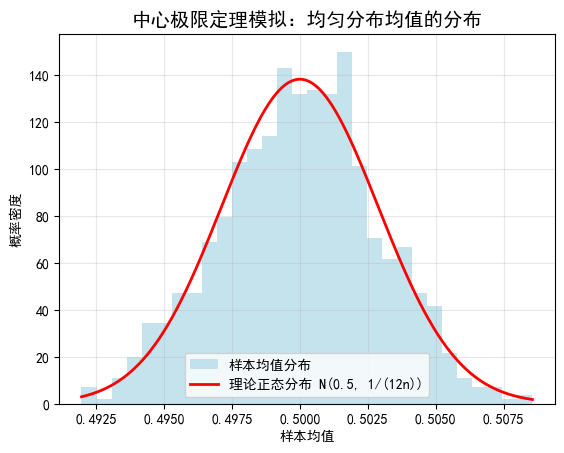

In [2]:
# 导入需要的库
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ===================== 任务1：生成数据并计算均值 =====================
n = 10000    # 每次生成 10000 个均匀分布随机数
m = 1000     # 重复 1000 次
mean_list = []

for i in range(m):
    # 生成 U(0,1) 均匀分布随机数（补全括号，修复语法错误）
    data = np.random.uniform(0, 1, n)
    # 计算均值
    mean_val = np.mean(data)
    mean_list.append(mean_val)

# ===================== 任务3：计算均值的实际方差 =====================
real_var = np.var(mean_list, ddof=0)  # 显式指定总体方差，和理论值对齐
print("="*50)
print(f"1000个均值的实际方差 = {real_var:.8f}")
print(f"理论方差（1/(12n)） = {1/(12*n):.8f}")
print("="*50)

# ===================== 任务4：绘制直方图 + 正态分布曲线 =====================
plt.rcParams["font.family"] = ["SimHei"]  # 正常显示中文
plt.rcParams["axes.unicode_minus"] = False

# 绘制均值的直方图（归一化密度）
plt.hist(mean_list, bins=30, density=True, alpha=0.7, color="lightblue", label="样本均值分布")

# 理论正态分布参数
mu = 0.5           # 均匀分布 U(0,1) 的均值
sigma = np.sqrt(1 / (12 * n))  # 理论标准差

# 生成x轴数据
x = np.linspace(min(mean_list), max(mean_list), 1000)
# 理论正态分布概率密度
y = norm.pdf(x, loc=mu, scale=sigma)

# 绘制理论曲线
plt.plot(x, y, "r-", linewidth=2, label="理论正态分布 N(0.5, 1/(12n))")
plt.title("中心极限定理模拟：均匀分布均值的分布", fontsize=14)
plt.xlabel("样本均值")
plt.ylabel("概率密度")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [3]:
import torch

# ===================== 1. 给定输入与参数 =====================
x = torch.tensor(2.0, requires_grad=False)  # 输入
w1 = torch.tensor(1.5, requires_grad=True)  # 需要求梯度
w2 = torch.tensor(0.5, requires_grad=True)

# ===================== 2. 前向传播 =====================
a = x * w1
b = a + w2
L = b ** 2  # L = b²

print("===== 前向传播结果 =====")
print(f"a = {a.item()}")
print(f"b = {b.item()}")
print(f"L = {L.item()}")

# ===================== 3. 反向传播（自动微分） =====================
L.backward()

# ===================== 4. 输出梯度 =====================
print("\n===== 自动计算梯度 =====")
print(f"dL/dw1 = {w1.grad.item()}")
print(f"dL/dw2 = {w2.grad.item()}")

# ===================== 5. 手动梯度（对比） =====================
print("\n===== 手动梯度结果 =====")
print(f"dL/dw1 = 14.0")
print(f"dL/dw2 = 7.0")

print("\n✅ 手动梯度 == PyTorch 自动梯度 → 结果一致！")

===== 前向传播结果 =====
a = 3.0
b = 3.5
L = 12.25

===== 自动计算梯度 =====
dL/dw1 = 14.0
dL/dw2 = 7.0

===== 手动梯度结果 =====
dL/dw1 = 14.0
dL/dw2 = 7.0

✅ 手动梯度 == PyTorch 自动梯度 → 结果一致！


In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ==============================================
# 1. 加载 MNIST 手写数字数据集（sklearn 版本）
# ==============================================
digits = load_digits()
X = digits.data  # 形状 (1797, 64)，8x8 图像展平
y = digits.target.reshape(-1, 1)  # 标签 (1797, 1)

print("数据集形状：", X.shape)
print("标签形状：", y.shape)

# ==============================================
# 2. 数据预处理：OneHot 编码 + 训练测试集划分
# ==============================================
# OneHot 编码标签
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# 划分训练集、测试集 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

# 数据归一化（0~255 → 0~1）
X_train = X_train / 16.0
X_test = X_test / 16.0

print("训练集 X：", X_train.shape)
print("训练集 y：", y_train.shape)
print("测试集 X：", X_test.shape)
print("测试集 y：", y_test.shape)

# ==============================================
# 3. 从零实现 Softmax 函数
# ==============================================
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 防溢出
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ==============================================
# 4. 从零实现 交叉熵损失函数
# ==============================================
def cross_entropy_loss(y_pred, y_true):
    n_samples = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n_samples  # 防 log(0)
    return loss

# ==============================================
# 5. 小批量梯度下降（核心）
# ==============================================
def batch_gradient(X, y, W):
    n = X.shape[0]
    z = np.dot(X, W)
    y_pred = softmax(z)
    grad = np.dot(X.T, (y_pred - y)) / n
    return grad

# ==============================================
# 6. 准确率计算
# ==============================================
def accuracy(y_pred, y_true):
    pred_label = np.argmax(y_pred, axis=1)
    true_label = np.argmax(y_true, axis=1)
    return np.mean(pred_label == true_label)

# ==============================================
# 7. 训练参数设置（题目要求）
# ==============================================
input_dim = 64    # 8x8 展平
num_classes = 10  # 0~9
lr = 0.1          # 学习率
batch_size = 32   # 批量大小
epochs = 50       # 训练轮次

# 初始化权重 W
W = np.random.randn(input_dim, num_classes) * 0.01

# ==============================================
# 8. 开始训练（小批量 SGD）
# ==============================================
print("\n===== 开始训练 =====")
n_train = X_train.shape[0]

for epoch in range(epochs):
    # 打乱数据
    indices = np.arange(n_train)
    np.random.shuffle(indices)
    X_shuffle = X_train[indices]
    y_shuffle = y_train[indices]

    total_loss = 0
    n_batches = n_train // batch_size

    # 小批量循环
    for i in range(n_batches):
        X_batch = X_shuffle[i*batch_size : (i+1)*batch_size]
        y_batch = y_shuffle[i*batch_size : (i+1)*batch_size]

        # 梯度下降
        grad = batch_gradient(X_batch, y_batch, W)
        W -= lr * grad

        # 损失
        z_batch = np.dot(X_batch, W)
        y_pred_batch = softmax(z_batch)
        loss = cross_entropy_loss(y_pred_batch, y_batch)
        total_loss += loss

    # 每轮输出
    avg_loss = total_loss / n_batches
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | 损失 = {avg_loss:.4f}")

# ==============================================
# 9. 测试集评估（题目要求输出准确率）
# ==============================================
print("\n===== 测试集结果 =====")
z_test = np.dot(X_test, W)
y_pred_test = softmax(z_test)
test_acc = accuracy(y_pred_test, y_test)

print(f"测试集准确率 = {test_acc:.4f} ({test_acc*100:.2f}%)")
print("\n✅ Softmax 回归 MNIST 分类完成！")

数据集形状： (1797, 64)
标签形状： (1797, 1)
训练集 X： (1437, 64)
训练集 y： (1437, 10)
测试集 X： (360, 64)
测试集 y： (360, 10)

===== 开始训练 =====
Epoch [1/50] | 损失 = 1.8968
Epoch [10/50] | 损失 = 0.4542
Epoch [20/50] | 损失 = 0.2992
Epoch [30/50] | 损失 = 0.2398
Epoch [40/50] | 损失 = 0.2081
Epoch [50/50] | 损失 = 0.1847

===== 测试集结果 =====
测试集准确率 = 0.9639 (96.39%)

✅ Softmax 回归 MNIST 分类完成！


训练集 X shape: (400, 2)
训练集 y shape: (400,)
测试集 X shape: (100, 2)
测试集 y shape: (100,)

===== 开始训练 =====
Epoch [100/1000], Loss = 0.2001
Epoch [200/1000], Loss = 0.1392
Epoch [300/1000], Loss = 0.1123
Epoch [400/1000], Loss = 0.0970
Epoch [500/1000], Loss = 0.0870
Epoch [600/1000], Loss = 0.0799
Epoch [700/1000], Loss = 0.0746
Epoch [800/1000], Loss = 0.0704
Epoch [900/1000], Loss = 0.0671
Epoch [1000/1000], Loss = 0.0643

训练完成！
w = [1.6361967  1.41185434]
b = -4.138335953633856

测试集准确率 = 0.9800 (98.00%)


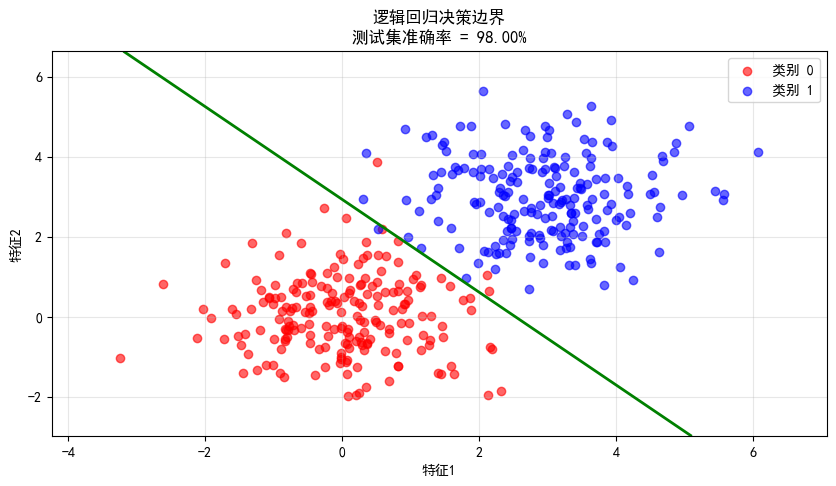

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ==============================================
# 1. 生成线性可分的二分类数据（每类200个，特征维度2）
# ==============================================
np.random.seed(42)  # 固定随机种子，结果可复现

n_samples = 200
# 类别 0：均值 [0, 0]
X0 = np.random.randn(n_samples, 2) + np.array([0, 0])
y0 = np.zeros(n_samples)

# 类别 1：均值 [3, 3]（线性可分）
X1 = np.random.randn(n_samples, 2) + np.array([3, 3])
y1 = np.ones(n_samples)

# 合并数据
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

# 生成测试集（每类50个，共100个）
X0_test = np.random.randn(50, 2) + np.array([0, 0])
X1_test = np.random.randn(50, 2) + np.array([3, 3])
X_test = np.vstack((X0_test, X1_test))
y_test = np.hstack((np.zeros(50), np.ones(50)))

print("训练集 X shape:", X.shape)
print("训练集 y shape:", y.shape)
print("测试集 X shape:", X_test.shape)
print("测试集 y shape:", y_test.shape)


# ==============================================
# 2. 定义 sigmoid 函数 + 二元交叉熵损失
# ==============================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8  # 防止 log(0)
    loss = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    return loss


# ==============================================
# 3. 梯度下降训练逻辑回归（lr=0.1，迭代1000次）
# ==============================================
# 参数初始化
w = np.zeros(2)
b = 0.0
lr = 0.1
epochs = 1000
loss_history = []

print("\n===== 开始训练 =====")
for i in range(epochs):
    # 前向传播
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    # 计算损失
    loss = binary_cross_entropy(y, y_pred)
    loss_history.append(loss)

    # 计算梯度
    dw = np.dot(X.T, (y_pred - y)) / len(y)
    db = np.mean(y_pred - y)

    # 更新参数
    w -= lr * dw
    b -= lr * db

    # 每100轮打印一次
    if (i + 1) % 100 == 0:
        print(f"Epoch [{i + 1}/{epochs}], Loss = {loss:.4f}")

print("\n训练完成！")
print(f"w = {w}")
print(f"b = {b}")


# ==============================================
# 4. 计算测试集准确率
# ==============================================
def predict(X, w, b):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    return (y_pred >= 0.5).astype(int)  # 大于0.5判为1，否则0


# 预测
y_pred_test = predict(X_test, w, b)
accuracy = np.mean(y_pred_test == y_test)
print(f"\n测试集准确率 = {accuracy:.4f} ({accuracy * 100:.2f}%)")

# ==============================================
# 5. 绘制决策边界 + 数据分布图
# ==============================================
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 5))

# 绘制样本点
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="red", label="类别 0", alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", label="类别 1", alpha=0.6)

# 绘制决策边界
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))
Z = sigmoid(w[0] * xx1 + w[1] * xx2 + b)
Z = Z.reshape(xx1.shape)

# 画分界线（概率=0.5）
plt.contour(xx1, xx2, Z, levels=[0.5], colors="green", linewidths=2, label="决策边界")

plt.xlabel("特征1")
plt.ylabel("特征2")
plt.title(f"逻辑回归决策边界\n测试集准确率 = {accuracy * 100:.2f}%")
plt.legend()
plt.grid(alpha=0.3)
plt.show()